In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. NASTAVITVE
# ============================================================
# Odstranjene: Q(16), W(22), X(23), Y(24) -> indeksi v EMNIST byclass so 10+
excluded_letters = {'Q', 'W', 'X', 'Y'}

labels_ordered = [l for l in 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' if l not in excluded_letters]
n_classes = len(labels_ordered)  # 22

# Originalni EMNIST indeksi za A-Z so 10-35
# Filtriramo ven Q=26, W=32, X=33, Y=34
excluded_emnist = {ord(l) - ord('A') + 10 for l in excluded_letters}  # {26, 32, 33, 34}

# Mapa: originalni label -> novi zaporedni indeks (0..21)
valid_labels = [i for i in range(10, 36) if i not in excluded_emnist]
label_remap = {orig: new for new, orig in enumerate(valid_labels)}

BITMAP_SAMPLE_COUNT = 2968
PER_CLASS = BITMAP_SAMPLE_COUNT // 22  # ~134 na črko
BATCH_SIZE = 16

# ============================================================
# 2. NALOŽI IN PRED-OBDELAJ PODATKE
# ============================================================
print("Nalaganje EMNIST byclass...")
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/byclass',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

# Lookup tabela za remapiranje labelov
keys   = tf.constant(list(label_remap.keys()),   dtype=tf.int64)
values = tf.constant(list(label_remap.values()), dtype=tf.int64)
table  = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys, values),
    default_value=-1
)


Nalaganje EMNIST byclass...


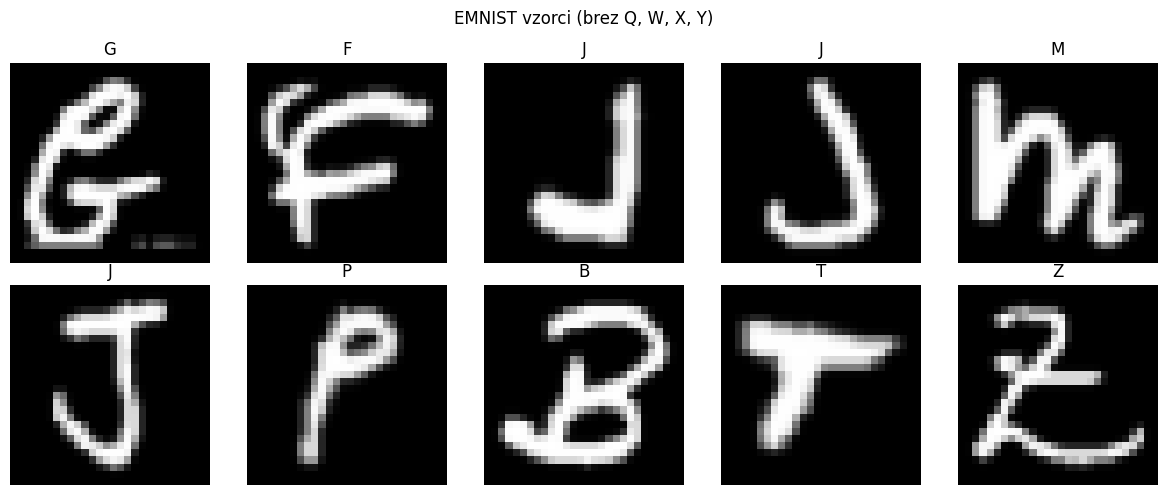

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape (Reshape)                    │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ separable_conv2d (SeparableConv2D)   │ (None, 28, 28, 16)          │              41 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ separable_conv2d_1 (SeparableConv2D) │ (None, 14, 14, 32)          │             688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 22)                  │             726 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,839 (22.81 KB)

 Trainable params: 5,743 (22.43 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/100
    180/Unknown 4s 5ms/step - accuracy: 0.0725 - loss: 3.0575

C:\Users\Ksenija\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.1035 - loss: 2.9917 - val_accuracy: 0.0976 - val_loss: 3.0670
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.1703 - loss: 2.6643 - val_accuracy: 0.1610 - val_loss: 2.8703
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2398 - loss: 2.3489 - val_accuracy: 0.2526 - val_loss: 2.4375
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.2829 - loss: 2.1818 - val_accuracy: 0.2787 - val_loss: 2.3952
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.3206 - loss: 2.0564 - val_accuracy: 0.4544 - val_loss: 1.8243
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3745 - loss: 1.9093 - val_accuracy: 0.2597 - val_loss: 2.2749
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.4152 - loss: 1.7903 - val_accuracy: 0.5143 - val_loss: 1.6206
Epoch 8/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4484 - loss: 1.6817 - val_accurac

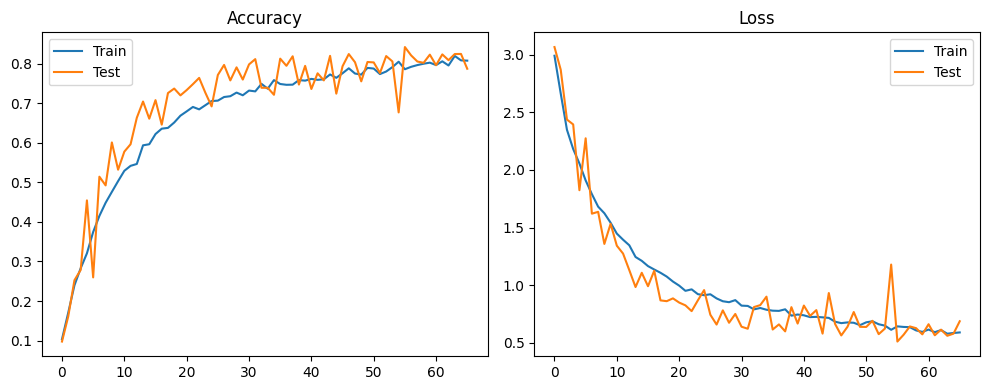

In [2]:
def filter_and_preprocess(image, label):
    label = tf.cast(label, tf.int64)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.transpose(image, perm=[1, 0, 2])  # EMNIST rotacija
    image = tf.reshape(image, (784,))
    new_label = table.lookup(label)
    return image, new_label

def is_valid(image, label):
    label = tf.cast(label, tf.int64)
    return tf.reduce_any(tf.equal(keys, label))

# da uzame enak št vzorcev na pos črko
ds_parts = []
for orig_label in valid_labels:  # valid_labels = [10,11,...,35 brez Q/W/X/Y]
    ds_part = (ds_train
        .filter(lambda img, lbl, ol=orig_label: tf.cast(lbl, tf.int64) == ol)
        .map(filter_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .take(PER_CLASS)
    )
    ds_parts.append(ds_part)

# združ vse razrede
from functools import reduce
ds_train = reduce(lambda a, b: a.concatenate(b), ds_parts)

ds_train = (ds_train
    .cache()
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

ds_test = (ds_test
    .filter(is_valid)
    .map(filter_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE))

# ============================================================
# 3. VIZUALIZACIJA
# ============================================================
sample_images, sample_labels = next(iter(ds_train))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    axes[i//5][i%5].imshow(sample_images[i].numpy().reshape(28, 28), cmap='gray')
    axes[i//5][i%5].set_title(labels_ordered[sample_labels[i].numpy()])
    axes[i//5][i%5].axis('off')
plt.suptitle('EMNIST vzorci (brez Q, W, X, Y)')
plt.tight_layout()
plt.show()

# ============================================================
# 4. MODEL
# ============================================================
emnist_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Reshape((28, 28, 1)),
    
    tf.keras.layers.SeparableConv2D(16, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    
    tf.keras.layers.SeparableConv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    #tf.keras.layers.Flatten(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(n_classes, activation='softmax')  # 22 razredov
])

emnist_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
emnist_model.summary()

# ============================================================
# 5. TRENING
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = emnist_model.fit(
    ds_train,
    epochs=100,
    validation_data=ds_test,
    callbacks=[early_stop],
    verbose=1
)

# ============================================================
# 6. REZULTATI
# ============================================================
_, train_acc = emnist_model.evaluate(ds_train, verbose=0)
_, test_acc  = emnist_model.evaluate(ds_test,  verbose=0)
print(f"\nTrain accuracy: {train_acc*100:.1f}%")
print(f"Test accuracy:  {test_acc*100:.1f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()

INFO:tensorflow:Assets written to: C:\Users\Ksenija\AppData\Local\Temp\tmpt_v3cglr\assets


INFO:tensorflow:Assets written to: C:\Users\Ksenija\AppData\Local\Temp\tmpt_v3cglr\assets


Saved artifact at 'C:\Users\Ksenija\AppData\Local\Temp\tmpt_v3cglr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 22), dtype=tf.float32, name=None)
Captures:
  1816305423120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305424080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305425040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305426000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305426192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305424272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305425232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305426576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305425616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305425424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1816305427

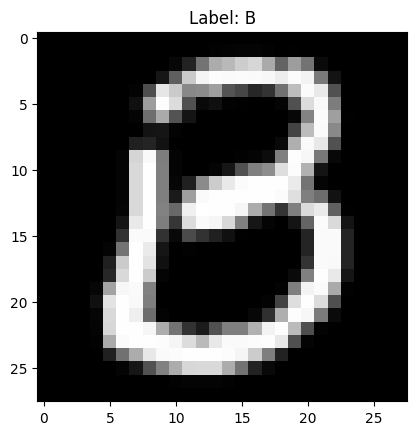

In [3]:
# ============================================================
# 7. PRETVORBA V TFLITE (Kvantizacija na 8-bit)
# ============================================================
converter = tf.lite.TFLiteConverter.from_keras_model(emnist_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(r'F:\FRI_DIPLOMSKA\-delovna mapa-\MODEL\bitmaps\emnist-redu.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model shranjen: {len(tflite_model) / 1024:.1f} KB")

# Vizualizacija vzorca
for img, label in ds_train.take(1):
    plt.imshow(img[0].numpy().reshape(28, 28), cmap='gray')
    plt.title(f"Label: {labels_ordered[label[0].numpy()]}")
    plt.show()


In [4]:
import struct
# ============================================================
# 8. IZVOZ TESTNIH VZORCEV
# ============================================================
def export_emnist_benchmark(ds, filename=r"F:\FRI_DIPLOMSKA\-delovna mapa-\MODEL\bitmaps\zbirka_emnist.bin", max_samples=225):
    count = 0
    with open(filename, "wb") as f:
        for batch_images, batch_labels in ds:
            images = batch_images.numpy()
            labels = batch_labels.numpy()
            for i in range(len(images)):
                if count >= max_samples:
                    break
                pixels = images[i].flatten().astype(np.float32)
                assert len(pixels) == 784
                label = int(labels[i])
                data = struct.pack('<BH784f', label, 784, *pixels)
                f.write(data)
                count += 1
            if count >= max_samples:
                break
    print(f"Končano! {count} vzorcev shranjenih v '{filename}'")

export_emnist_benchmark(ds_test)

Končano! 225 vzorcev shranjenih v 'F:\FRI_DIPLOMSKA\-delovna mapa-\MODEL\bitmaps\zbirka_emnist.bin'


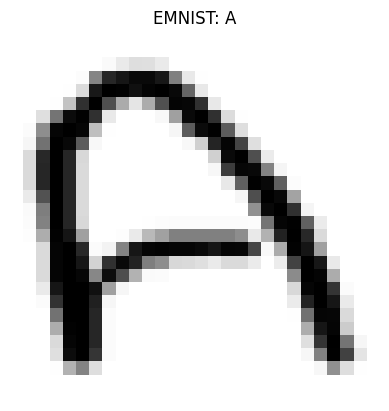

In [5]:
for img, label in ds_train.unbatch().filter(lambda img, lbl: lbl == 0).batch(1).take(1):
    plt.imshow(img[0].numpy().reshape(28, 28), cmap='gray_r')  # <-- gray_r invertira
    plt.title(f"EMNIST: A")
    plt.axis('off')
    plt.show()

In [7]:
# ============================================================
# IZVOZ ČRKE KOT SVG ZA LATEX
# ============================================================
CRKA_ZA_IZVOZ = 'A'
SVG_POT = r'F:\FRI_DIPLOMSKA\-delovna mapa-\JUPY\ektorji_za_latex' + f'\\emnist_redu_{CRKA_ZA_IZVOZ}.pdf'

crka_idx = labels_ordered.index(CRKA_ZA_IZVOZ)

# Vzemi prvi vzorec te črke iz ds_train
for img, label in ds_train.unbatch().filter(lambda img, lbl: lbl == crka_idx).take(1):
    sample = img.numpy().reshape(28, 28)

fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(sample, cmap='gray_r', interpolation='nearest')
ax.axis('off')

plt.savefig(SVG_POT, format='pdf', bbox_inches='tight', pad_inches=0)
plt.close()

print(f"Shranjeno: {SVG_POT}")

Shranjeno: F:\FRI_DIPLOMSKA\-delovna mapa-\JUPY\ektorji_za_latex\emnist_redu_A.pdf
